In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,classification_report,roc_auc_score,roc_curve
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

import warnings
warnings.filterwarnings("ignore")



In [3]:
df=pd.read_csv("heart_failure_clinical_records_dataset.csv")
df

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280,0


In [4]:
df.shape

(299, 13)

In [5]:
df.isnull().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.shape

(299, 13)

In [8]:
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [9]:
df.dtypes

age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,299.0,60.833893,11.894809,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.431438,0.496107,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.418060,0.494067,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.351171,0.478136,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.648829,0.478136,0.0,0.0,1.0,1.0,1.0


In [11]:
df.isnull().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [12]:

# -----------------------------
# 5. Distribution & Outlier Analysis
# -----------------------------

In [13]:
num_feature=['age','serum_creatinine','ejection_fraction']

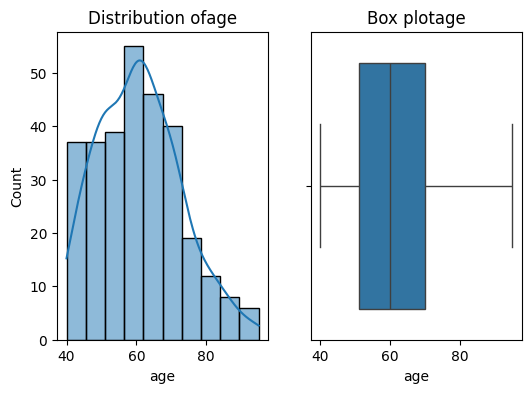

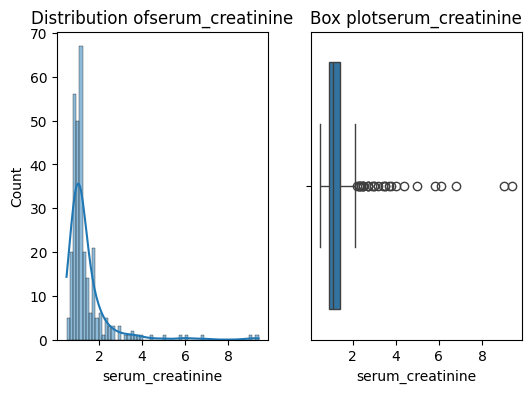

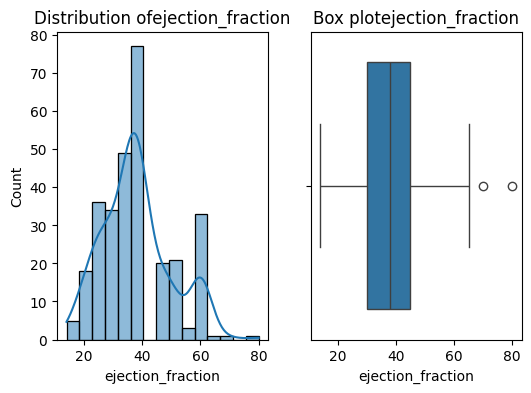

In [45]:
for col in num_feature:
    plt.figure(figsize=(6,4))

    plt.subplot(1,2,1)
    sns.histplot(df[col],kde=True)
    plt.title(f"Distribution of{col}")

    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.title(f"Box plot{col}")
    plt.show()

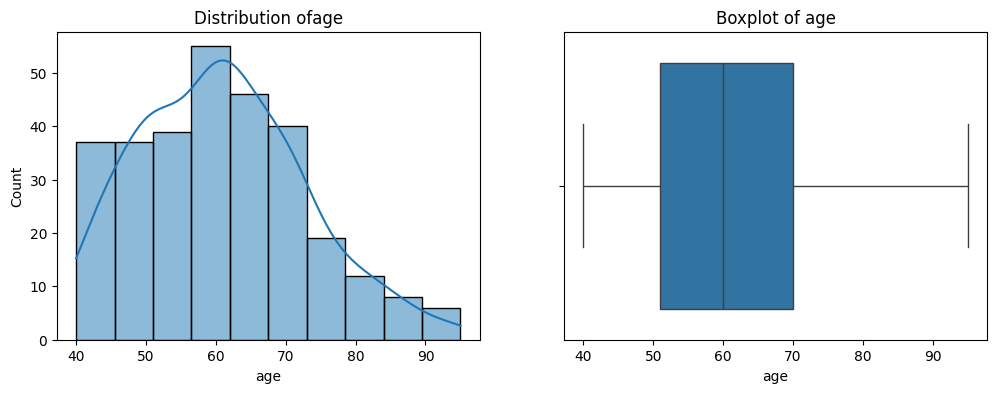

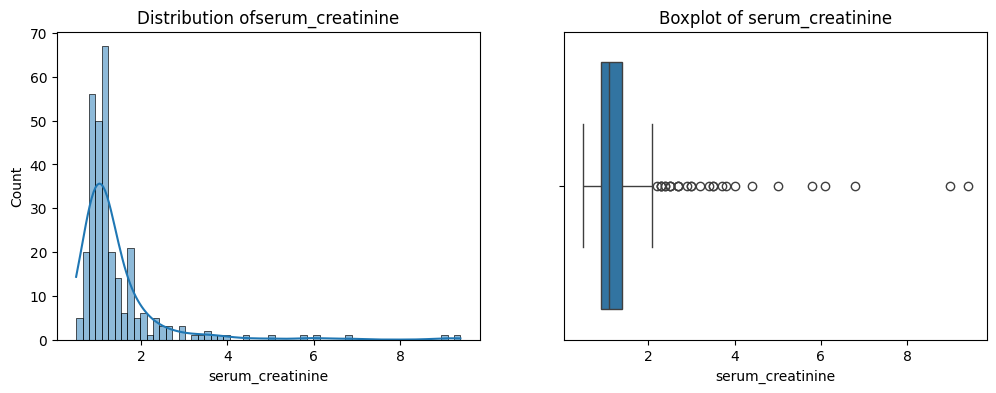

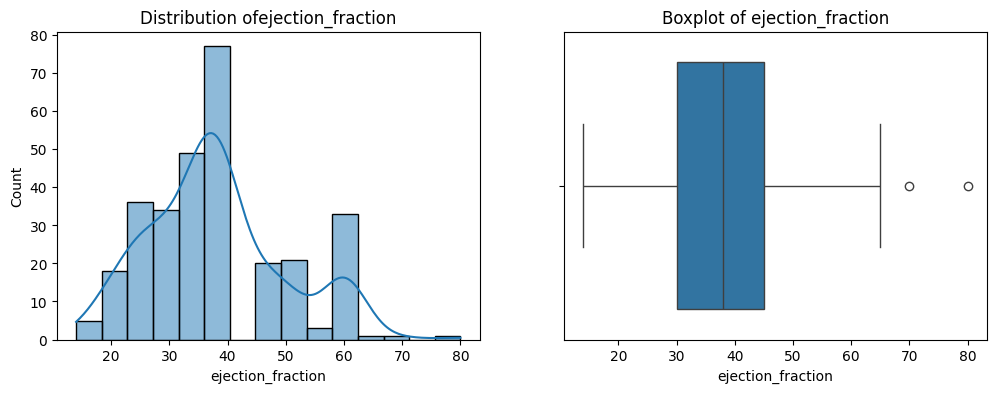

In [15]:
for col in num_feature:
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    sns.histplot(df[col],kde=True)
    plt.title(f"Distribution of{col}")

    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()




In [16]:

# -----------------------------
# 6. Numerical Features vs Target
# -----------------------------

In [17]:
binary_rel_feature=['age','ejection_fraction','serum_creatinine']


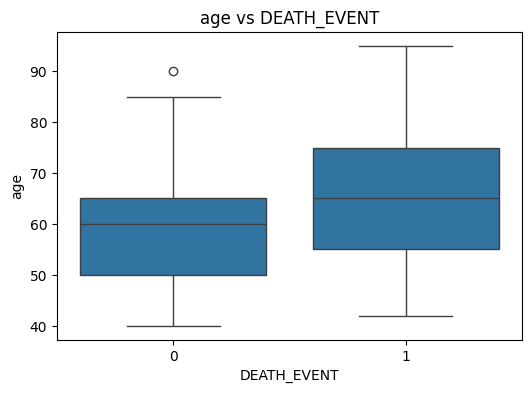

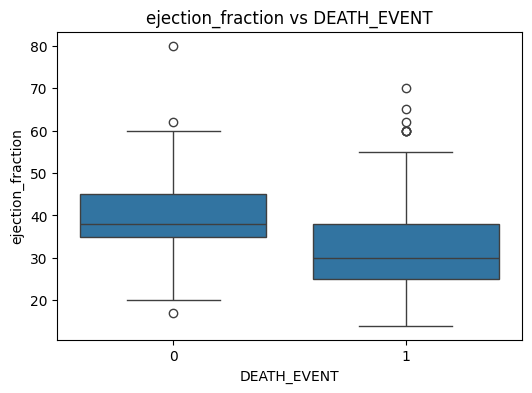

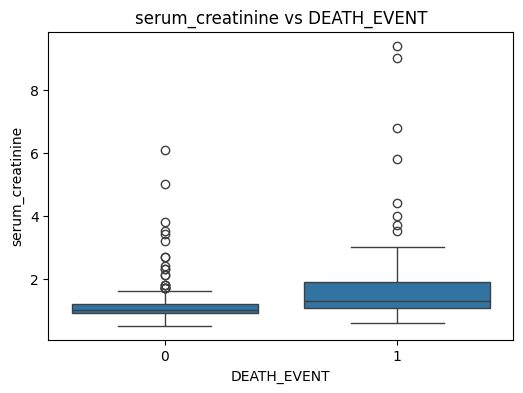

In [18]:
for col in binary_rel_feature:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='DEATH_EVENT',y=col,data=df)
    plt.title(f"{col} vs DEATH_EVENT")
    plt.show()

In [19]:
# -----------------------------
# 7. Categorical Feature Analysis
# -----------------------------

In [20]:
cat_freture=['sex','diabetes','smoking','high_blood_pressure','anaemia']

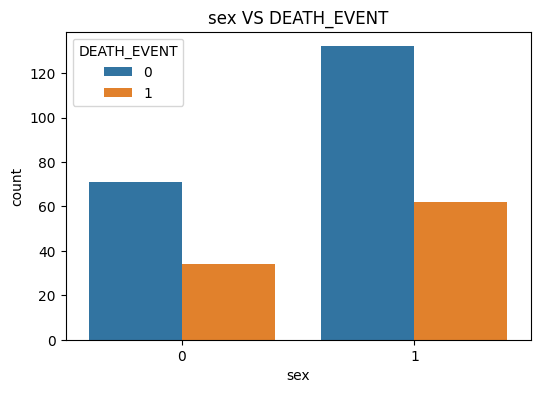

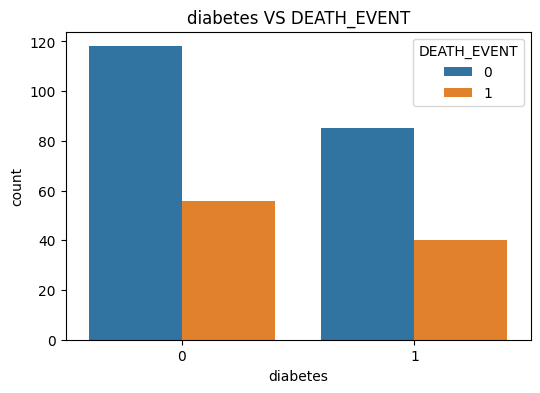

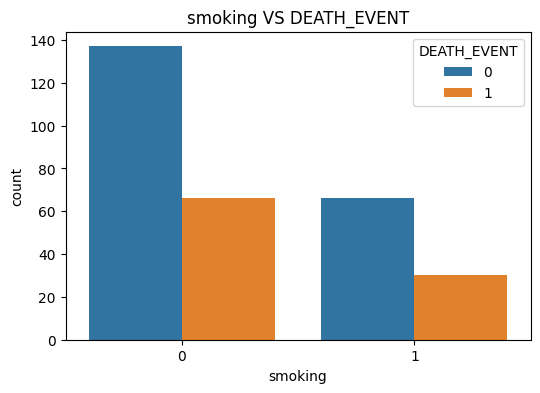

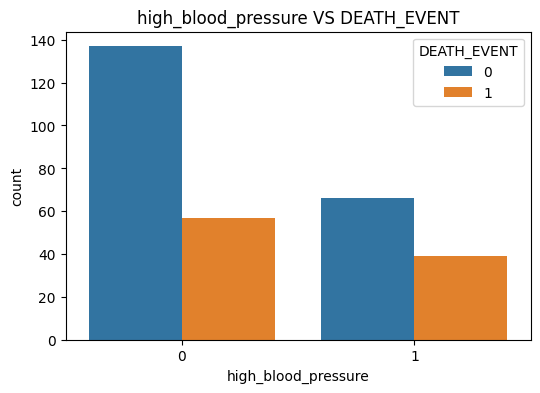

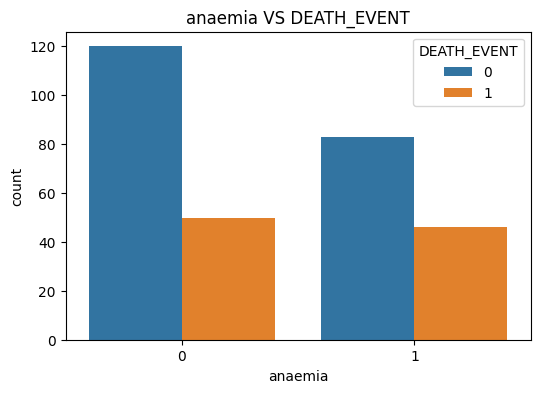

In [21]:
for col in cat_freture:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col,hue='DEATH_EVENT',data=df)
    plt.title(f"{col} VS DEATH_EVENT")
    plt.show()
    

In [22]:
# -----------------------------
# 8. Group Analysis (Age Groups)
# -----------------------------

In [23]:
df['age_group']=pd.cut(
    df['age'],
    bins=[0,50,65,100],
    labels=["<=50","51-65",">65"])


In [24]:
age_group_death=df.groupby("age_group")["DEATH_EVENT"].mean()
print("\nDeath Rate by Age group:\n")
print(age_group_death)


Death Rate by Age group:

age_group
<=50     0.256757
51-65    0.257353
>65      0.471910
Name: DEATH_EVENT, dtype: float64


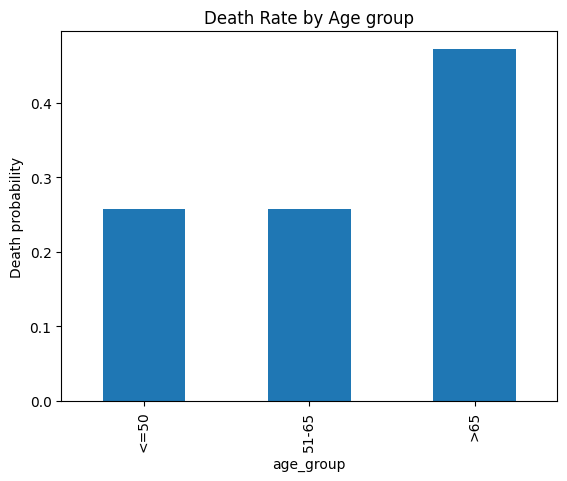

In [25]:
age_group_death.plot(kind='bar',title="Death Rate by Age group")
plt.ylabel("Death probability")
plt.show()

In [26]:

# -----------------------------
# 9. Correlation Analysis
# -----------------------------

In [27]:
# plt.figure(figsize=(10,8))
# sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
# plt.title("Correlation Heatmap")
# plt.show()

In [28]:
# 10 Model Building

x=df.drop(["DEATH_EVENT","age_group"],axis=1)
y=df['DEATH_EVENT']

x_train,x_test,y_train,y_test =train_test_split(x,y,test_size=0.25,random_state=42)

In [29]:
# 11 Feature Scalling
scaler =StandardScaler()
x_train_scaled =scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)


In [30]:
#12 Logistic Regression Model

model =LogisticRegression()
model.fit(x_train_scaled,y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [31]:
# 13 Model evaluation

y_pred =model.predict(x_test_scaled)
y_prob=model.predict_proba(x_test_scaled)[:,1]

In [32]:
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test,y_pred))


Confusion Matrix:

[[41  3]
 [14 17]]


In [33]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.93      0.83        44
           1       0.85      0.55      0.67        31

    accuracy                           0.77        75
   macro avg       0.80      0.74      0.75        75
weighted avg       0.79      0.77      0.76        75



In [34]:
roc_auc=roc_auc_score(y_test,y_prob)
print("Roc-AUC score:",roc_auc)

Roc-AUC score: 0.8137829912023461


In [35]:
# -----------------------------
# 14. ROC Curve
# -----------------------------

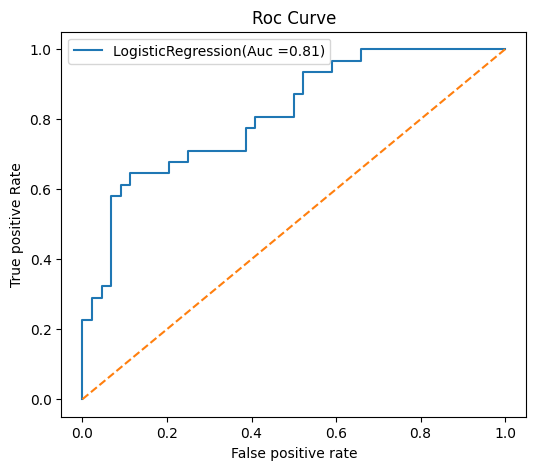

In [36]:
# 14 roc curve

fpr,tpr,threshold=roc_curve(y_test,y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr,tpr,label=f"LogisticRegression(Auc ={roc_auc :.2f})")
plt.plot([0,1],[0,1],linestyle="--")
plt.xlabel("False positive rate")
plt.ylabel("True positive Rate")
plt.title("Roc Curve")
plt.legend()
plt.show()


# -----------------------------
# 15. Feature Importance (Coefficients)
# -----------------------------

In [37]:
coff_df =pd.DataFrame({
    "Feature":x.columns,
    "cofficient":model.coef_[0]
}).sort_values(by="cofficient",ascending=False)

print("\nLogistic Regression cofficient:\n")
print(coff_df)



Logistic Regression cofficient:

                     Feature  cofficient
7           serum_creatinine    0.805385
0                        age    0.684339
10                   smoking    0.189980
2   creatinine_phosphokinase    0.101087
3                   diabetes    0.091478
1                    anaemia   -0.064971
5        high_blood_pressure   -0.174841
6                  platelets   -0.260835
8               serum_sodium   -0.283893
9                        sex   -0.512831
4          ejection_fraction   -0.917594
11                      time   -1.730713


In [38]:
# for thresold
j=tpr-fpr
vth=threshold[j.argmax()]

new_y_pred=list(map(lambda x:1 if x>vth else 0,y_prob))
print(confusion_matrix(y_test,new_y_pred))
print(classification_report(y_test,new_y_pred))

[[39  5]
 [12 19]]
              precision    recall  f1-score   support

           0       0.76      0.89      0.82        44
           1       0.79      0.61      0.69        31

    accuracy                           0.77        75
   macro avg       0.78      0.75      0.76        75
weighted avg       0.78      0.77      0.77        75

